### Task 1

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [2]:
transform = transforms.ToTensor()

train_data = datasets.FashionMNIST(root="./data", train=True,  download=True, transform=transform)
test_data  = datasets.FashionMNIST(root="./data", train=False, download=True, transform=transform)

batch_size = 128
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(test_data,  batch_size=batch_size, shuffle=False)

class_names = ["T-shirt/top","Trouser","Pullover","Dress","Coat",
               "Sandal","Shirt","Sneaker","Bag","Ankle boot"]

print("Train images:", len(train_data), "| Test images:", len(test_data))

Train images: 60000 | Test images: 10000


In [ ]:
class VAE(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=400, latent_dim=20):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)

        self.fc2 = nn.Linear(latent_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, input_dim)

    def encode(self, x):
        h = F.relu(self.fc1(x))
        return self.fc_mu(h), self.fc_logvar(h)

    def reparametrize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + std * eps

    def decode(self, z):
        h = F.relu(self.fc2(z))
        return torch.sigmoid(self.fc3(h))

    def forward(self, x):
        x = x.view(x.size(0), -1)
        mu, logvar = self.encode(x)
        z = self.reparametrize(mu, logvar)
        x_recon = self.decode(z)
        return x_recon, mu, logvar

In [4]:
latent_dim = 20
model = VAE(input_dim=784, hidden_dim=400, latent_dim=latent_dim).to(device)
print(model)

VAE(
  (fc1): Linear(in_features=784, out_features=400, bias=True)
  (fc_mu): Linear(in_features=400, out_features=20, bias=True)
  (fc_logvar): Linear(in_features=400, out_features=20, bias=True)
  (fc2): Linear(in_features=20, out_features=400, bias=True)
  (fc3): Linear(in_features=400, out_features=784, bias=True)
)


In [5]:
def vae_loss(x_recon, x, mu, logvar):
    x = x.view(x.size(0), -1)
    recon_loss = F.binary_cross_entropy(x_recon, x, reduction="sum")
    kl_div = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + kl_div

In [6]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
epochs = 20

train_losses = []
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for images, _ in train_loader:
        images = images.to(device)
        optimizer.zero_grad()
        x_recon, mu, logvar = model(images)
        loss = vae_loss(x_recon, images, mu, logvar)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    avg_loss = running_loss / len(train_loader.dataset)
    train_losses.append(avg_loss)
    print(f"Epoch {epoch+1}/{epochs} | loss: {avg_loss:.2f}")

Epoch 1/20 | loss: 286.19
Epoch 2/20 | loss: 256.88
Epoch 3/20 | loss: 250.98
Epoch 4/20 | loss: 247.95
Epoch 5/20 | loss: 246.16
Epoch 6/20 | loss: 245.08
Epoch 7/20 | loss: 244.25
Epoch 8/20 | loss: 243.66
Epoch 9/20 | loss: 243.13
Epoch 10/20 | loss: 242.78
Epoch 11/20 | loss: 242.35
Epoch 12/20 | loss: 242.06
Epoch 13/20 | loss: 241.77
Epoch 14/20 | loss: 241.48
Epoch 15/20 | loss: 241.31
Epoch 16/20 | loss: 241.09
Epoch 17/20 | loss: 240.95
Epoch 18/20 | loss: 240.75
Epoch 19/20 | loss: 240.62
Epoch 20/20 | loss: 240.43


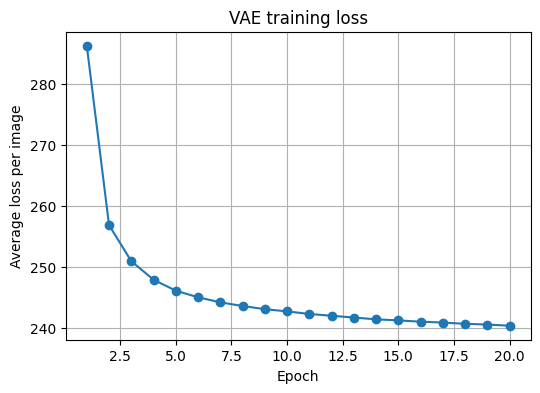

In [7]:
plt.figure(figsize=(6, 4))
plt.plot(range(1, epochs + 1), train_losses, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Average loss per image")
plt.title("VAE training loss")
plt.grid(True)
plt.show()

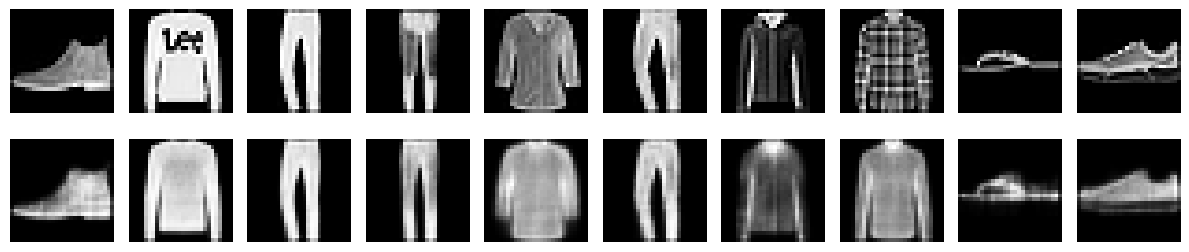

In [8]:
model.eval()
with torch.no_grad():
    images, _ = next(iter(test_loader))
    images = images.to(device)
    x_recon, _, _ = model(images)

n = 10
images = images.cpu().view(-1, 28, 28)
x_recon = x_recon.cpu().view(-1, 28, 28)

fig, axes = plt.subplots(2, n, figsize=(n * 1.2, 3))
for i in range(n):
    axes[0, i].imshow(images[i], cmap="gray")
    axes[0, i].axis("off")
    axes[1, i].imshow(x_recon[i], cmap="gray")
    axes[1, i].axis("off")
axes[0, 0].set_ylabel("original", rotation=0, labelpad=40)
axes[1, 0].set_ylabel("reconstructed", rotation=0, labelpad=40)
plt.tight_layout()
plt.show()

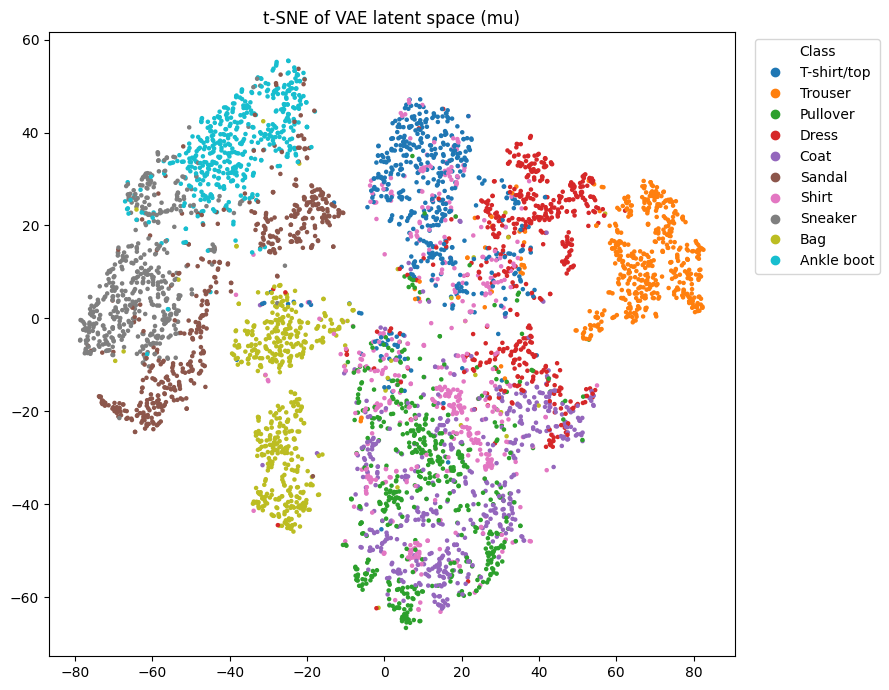

In [9]:
from sklearn.manifold import TSNE

model.eval()
all_mu = []
all_labels = []
N = 5000
count = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        mu, _ = model.encode(images.view(images.size(0), -1))
        all_mu.append(mu.cpu())
        all_labels.append(labels)
        count += images.size(0)
        if count >= N:
            break

all_mu = torch.cat(all_mu)[:N].numpy()
all_labels = torch.cat(all_labels)[:N].numpy()

tsne = TSNE(n_components=2, random_state=42)
mu_2d = tsne.fit_transform(all_mu)

plt.figure(figsize=(9, 7))
scatter = plt.scatter(mu_2d[:, 0], mu_2d[:, 1], c=all_labels, cmap="tab10", s=5)
handles, _ = scatter.legend_elements()
plt.legend(handles, class_names, title="Class", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.title("t-SNE of VAE latent space (mu)")
plt.tight_layout()
plt.show()

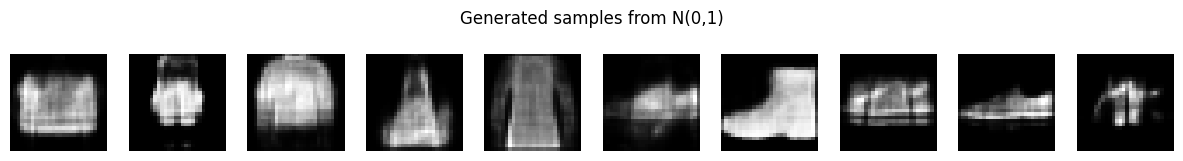

In [10]:
model.eval()
n_samples = 10

with torch.no_grad():
    z = torch.randn(n_samples, latent_dim).to(device)
    generated = model.decode(z)

generated = generated.cpu().view(-1, 28, 28)

fig, axes = plt.subplots(1, n_samples, figsize=(n_samples * 1.2, 1.6))
for i in range(n_samples):
    axes[i].imshow(generated[i], cmap="gray")
    axes[i].axis("off")
plt.suptitle("Generated samples from N(0,1)")
plt.tight_layout()
plt.show()

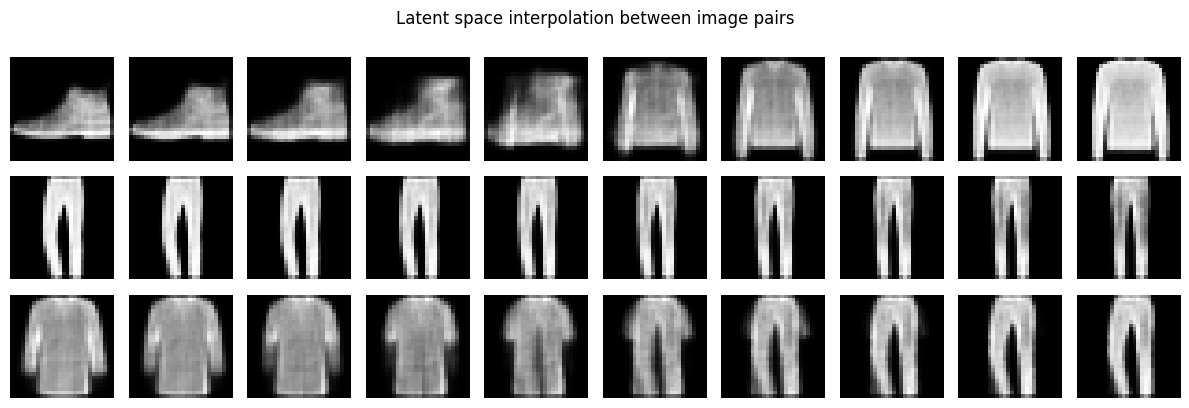

In [11]:
model.eval()

def interpolate(x1, x2, steps=10):
    with torch.no_grad():
        x1 = x1.to(device).view(1, -1)
        x2 = x2.to(device).view(1, -1)
        mu1, _ = model.encode(x1)
        mu2, _ = model.encode(x2)
        ts = torch.linspace(0, 1, steps).to(device)
        recons = []
        for t in ts:
            z = (1 - t) * mu1 + t * mu2
            recons.append(model.decode(z).cpu().view(28, 28))
    return recons

test_images, test_labels = next(iter(test_loader))

pairs = [(0, 1), (2, 3), (4, 5)]
steps = 10

fig, axes = plt.subplots(len(pairs), steps, figsize=(steps * 1.2, len(pairs) * 1.4))
for row, (i, j) in enumerate(pairs):
    recons = interpolate(test_images[i], test_images[j], steps=steps)
    for col, img in enumerate(recons):
        axes[row, col].imshow(img, cmap="gray")
        axes[row, col].axis("off")
plt.suptitle("Latent space interpolation between image pairs")
plt.tight_layout()
plt.show()

In [12]:
def recon_only_loss(x_recon, x, mu, logvar):
    x = x.view(x.size(0), -1)
    return F.binary_cross_entropy(x_recon, x, reduction="sum")

def kl_only_loss(x_recon, x, mu, logvar):
    return -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

In [13]:
def train_ablation(loss_fn, epochs=20, kl_only=False):
    abl_model = VAE(input_dim=784, hidden_dim=400, latent_dim=latent_dim).to(device)
    optimizer = torch.optim.Adam(abl_model.parameters(), lr=1e-3)
    for epoch in range(epochs):
        abl_model.train()
        running_loss = 0.0
        for images, _ in train_loader:
            images = images.to(device)
            optimizer.zero_grad()
            x_recon, mu, logvar = abl_model(images)
            loss = loss_fn(x_recon, images, mu, logvar)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        avg = running_loss / len(train_loader.dataset)
        print(f"  epoch {epoch+1}/{epochs} | loss: {avg:.2f}")
    return abl_model

In [20]:
print("Training reconstruction-only model:")
recon_only_model = train_ablation(recon_only_loss, epochs=20)

print("Training KL-only model:")
kl_only_model = train_ablation(kl_only_loss, epochs=5)

Training reconstruction-only model:
  epoch 1/20 | loss: 256.20
  epoch 2/20 | loss: 225.77
  epoch 3/20 | loss: 220.54


KeyboardInterrupt: 

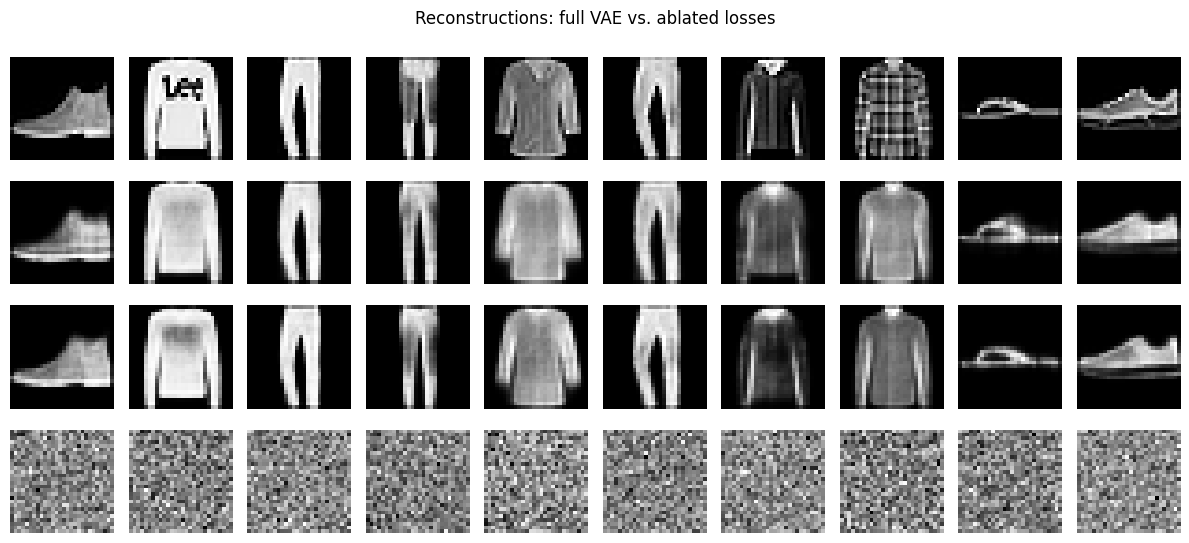

In [ ]:
for m in (model, recon_only_model, kl_only_model):
    m.eval()

with torch.no_grad():
    imgs, _ = next(iter(test_loader))
    imgs = imgs.to(device)
    recon_full = model(imgs)[0].cpu().view(-1, 28, 28)
    recon_ronly = recon_only_model(imgs)[0].cpu().view(-1, 28, 28)
    recon_klonly = kl_only_model(imgs)[0].cpu().view(-1, 28, 28)

originals = imgs.cpu().view(-1, 28, 28)
n = 10
rows = [("original", originals), ("full VAE", recon_full),
        ("recon-only", recon_ronly), ("KL-only", recon_klonly)]

fig, axes = plt.subplots(len(rows), n, figsize=(n * 1.2, len(rows) * 1.4))
for r, (label, batch) in enumerate(rows):
    for c in range(n):
        axes[r, c].imshow(batch[c], cmap="gray")
        axes[r, c].axis("off")
    axes[r, 0].set_ylabel(label, rotation=0, labelpad=45, va="center")
plt.suptitle("Reconstructions: full VAE vs. ablated losses")
plt.tight_layout()
plt.show()